# Seasonality

In [3]:
import xarray as xr
from pathlib import Path
from xhistogram.xarray import histogram as xhist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.patches as mpatches

In [2]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=3, memory_limit=24e9)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 12,Total memory: 89.41 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39369,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39157,Total threads: 3
Dashboard: http://127.0.0.1:40353/status,Memory: 22.35 GiB
Nanny: tcp://127.0.0.1:38807,


In [3]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

dask dashboard :D
https://jupyterhub.dkrz.de/user/b383184/levante-spawner-preset/proxy/8787/status


### Wet and Dry seasons

Precipitation varied seasonally, with a **wet season from mid-December 2000 to July 2001** characterized by successive rainy days, wet soil, and, relative to the dry season, cooler temperatures, greater cloudiness, and reduced incoming solar and net radiation (Rocha et al., 2004)

The seasonal cycle of the near-surface (~5 m below the sea surface) ocean salinity in the APR from multiple ocean-state estimate products shows the **freshest values in May–June–July** and the saltiest in **December–January–February** (Fig. 1d), which largely follows the seasonal cycle of the Amazon river discharge (Fig. 1c). Although the magnitude of the seasonal cycle varies with the chosen datasets, these ocean-state estimate datasets agree that the APR ocean salinity exhibits a similar seasonal evolution to the Amazon river discharge with no apparent lag

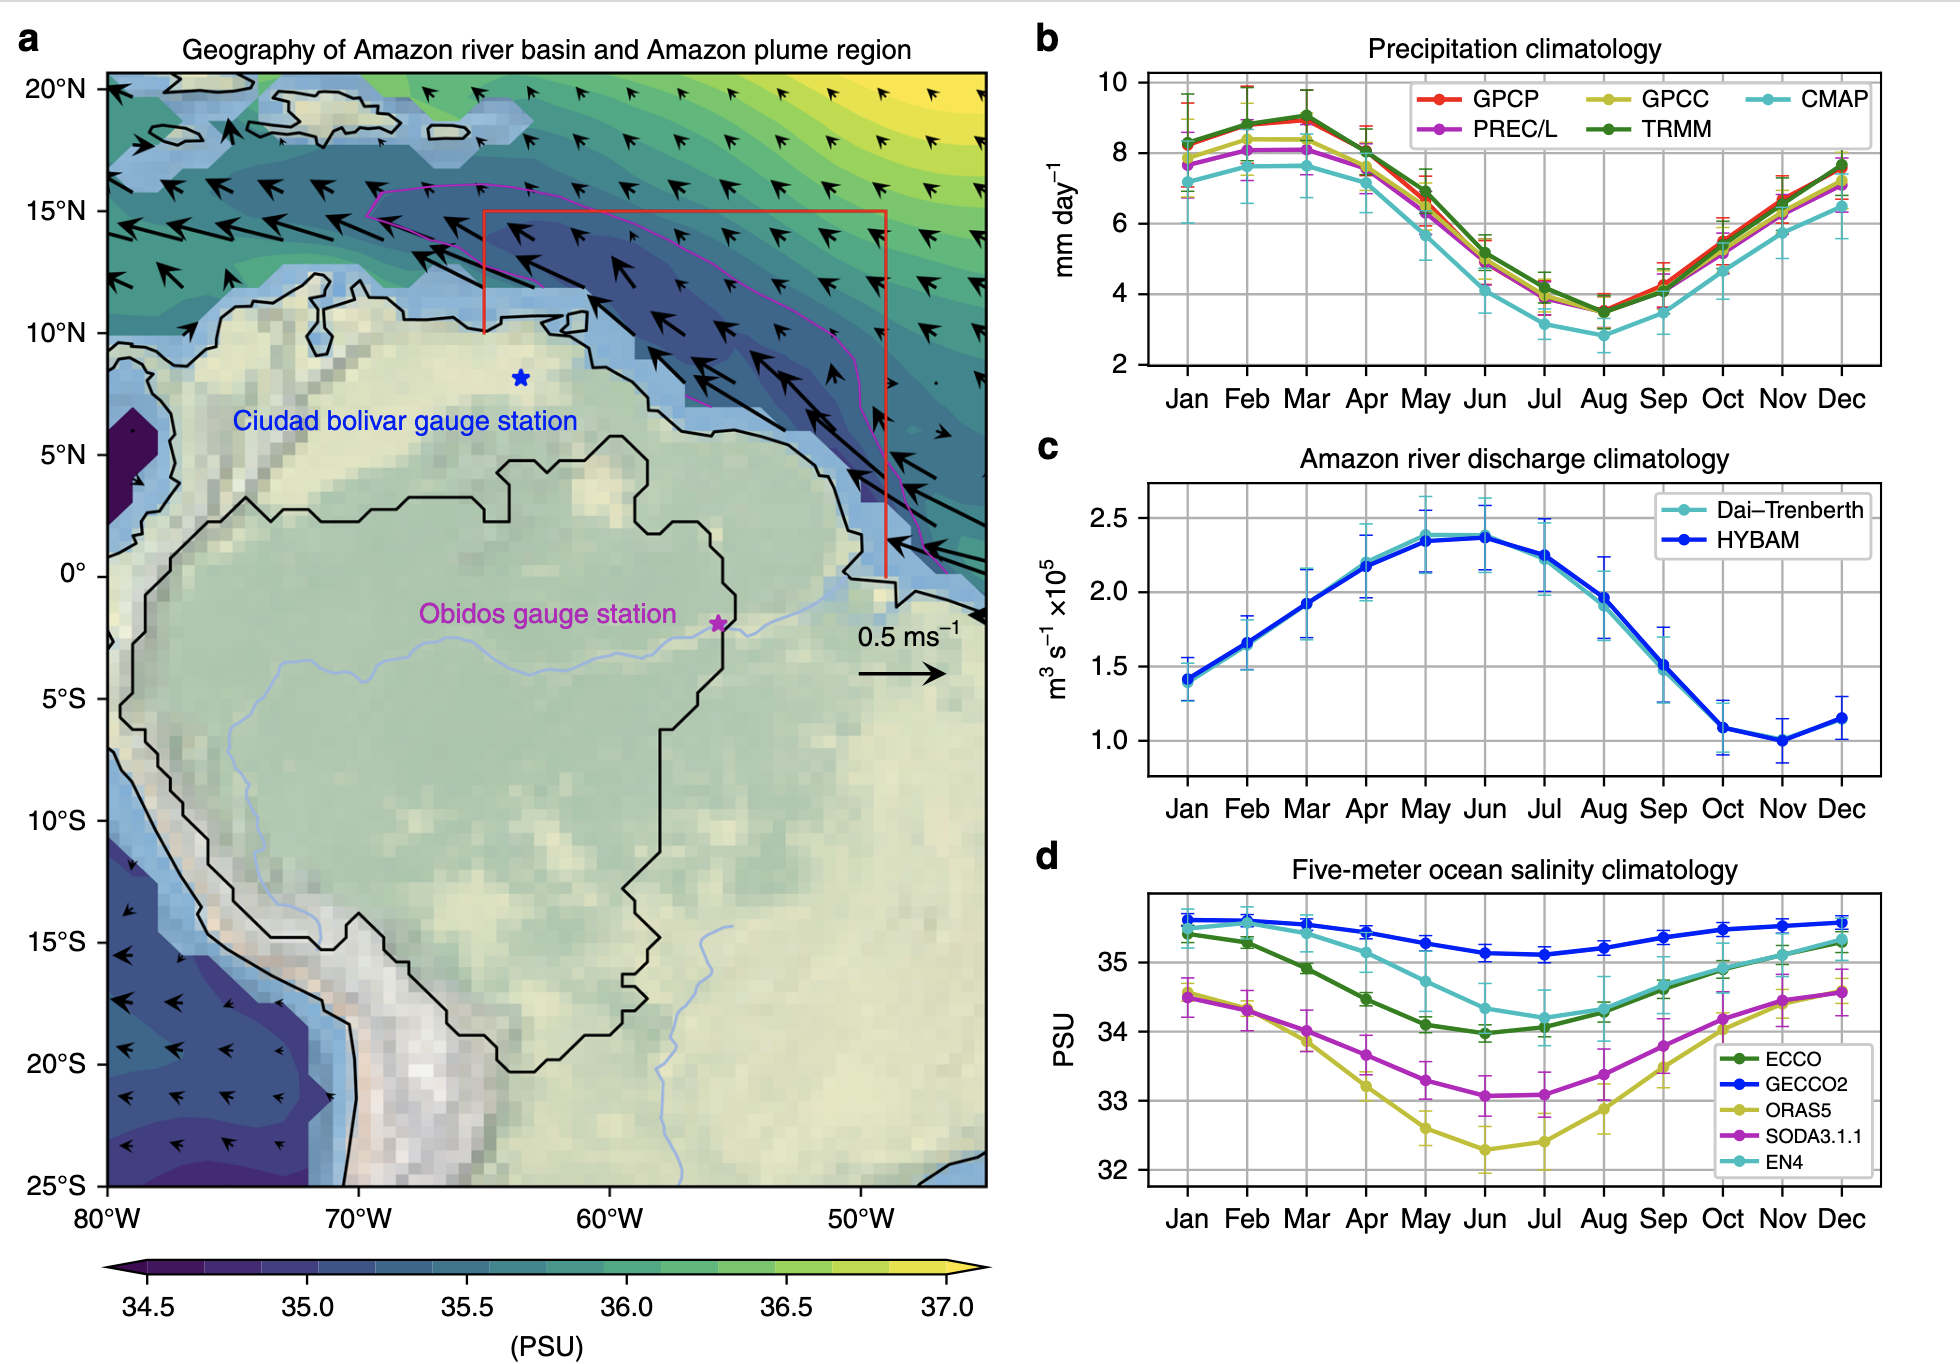

Liang et al., 

In [4]:
hist_month = xr.open_dataset("/work/bk1450/b383184/Amazon/Mercator/notebooks/seminar/_hist_month.nc").compute().histogram_lon_lat
hist_month

<xarray.DataArray 'histogram_lon_lat' (start_month: 12, obs: 37, lon: 79,
                                       lat: 29)> Size: 8MB
array([[[[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         ...,
...
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,   83,    0,    0],
         [   0,    0,    0, ...,  736,  272,    0],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]],

        [[   0,    0,    0, ...,    8,    0,    0],
         [   0,    0,    0, ...,  156,   19,    0],
         [   0,    0,    0, ..., 1216,  262,    8],
         ...,
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0],
         [   0,    0,    0, ...,    0,    0,    0]]]],
      shape=(12, 37, 79, 29))
Coordinates:
  * obs          (obs) float64 296B 10.5 30.5 50.5 70.5 ... 690.5 710.5 730.5
  * lon          (lon) float64 632B -94.31 -93.0 -91.7 ... 4.776 6.08 7.384
  * lat          (lat) float64 232B -7.067 -5.765 -4.464 ... 26.77 28.07 29.37
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


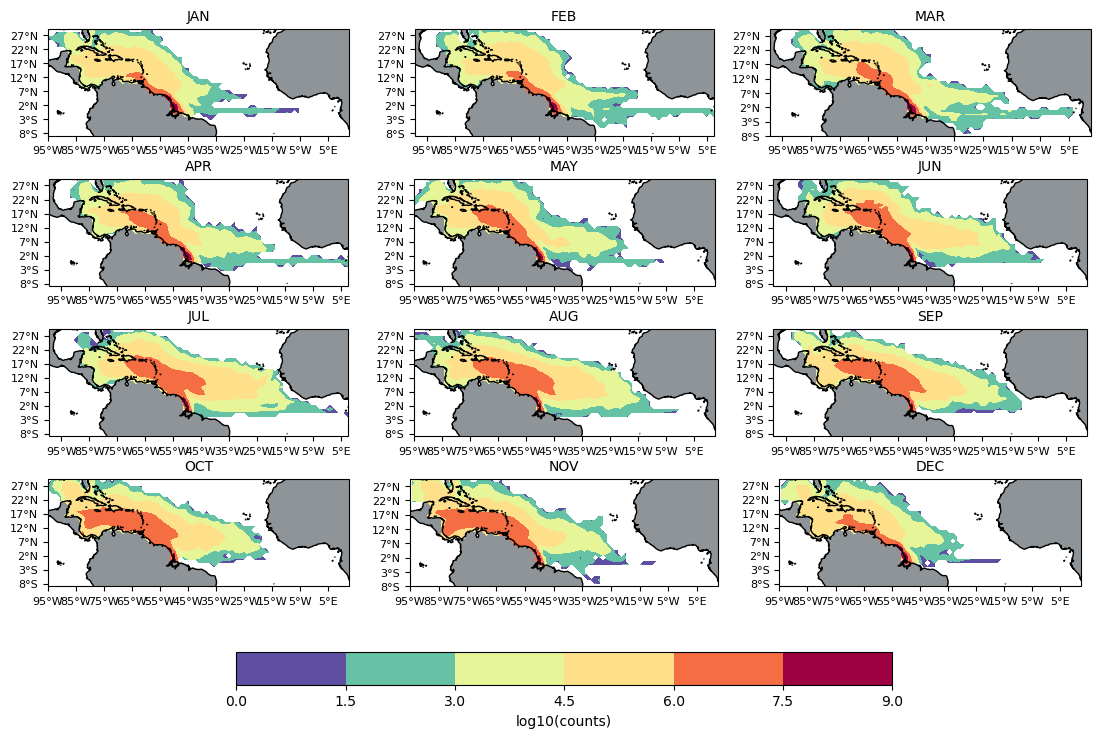

In [30]:
proj = ccrs.PlateCarree()
labs = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']

fig, ax = plt.subplots(
    4, 3,
    figsize=(12, 8),                      # a bit wider, not so tall
    subplot_kw=dict(projection=proj)
)
ax = ax.ravel()

for i in range(12):
    dd = hist_month.sel(start_month=i+1).sum("obs")

    # plot
    pcm = np.log10(dd).plot.contourf(
        x='lon', y='lat', ax=ax[i], transform=proj,
        add_colorbar=False, cmap='Spectral_r'
    )

    ax[i].coastlines()
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    ax[i].set_title(labs[i], fontsize=10)

    # ticks & labels
    ax[i].set_xticks(
        np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max()) + 1e-6, 10),
        crs=proj
    )
    ax[i].set_yticks(
        np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max()) + 1e-6, 5),
        crs=proj
    )
    ax[i].xaxis.set_major_formatter(
        LongitudeFormatter(number_format='.0f', degree_symbol='°')
    )
    ax[i].yaxis.set_major_formatter(
        LatitudeFormatter(number_format='.0f', degree_symbol='°')
    )
    ax[i].tick_params(labelsize=8)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')

# Tighter spacing: reduce both wspace and hspace
fig.subplots_adjust(
    left=0.05, right=0.95,
    bottom=0.08, top=0.90,
    wspace=0.05, hspace=0.4
)

# Optional: one shared colorbar at bottom
cbar = fig.colorbar(
    pcm, ax=ax, orientation='horizontal',
    fraction=0.05, pad=0.10
)
cbar.ax.set_xlabel('log10(counts)', fontsize=10)
# plt.savefig("figures/monthly_LPT.png", dpi=300, bbox_inches="tight")
plt.show()

### Replicating plot from coles et al., 2013

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


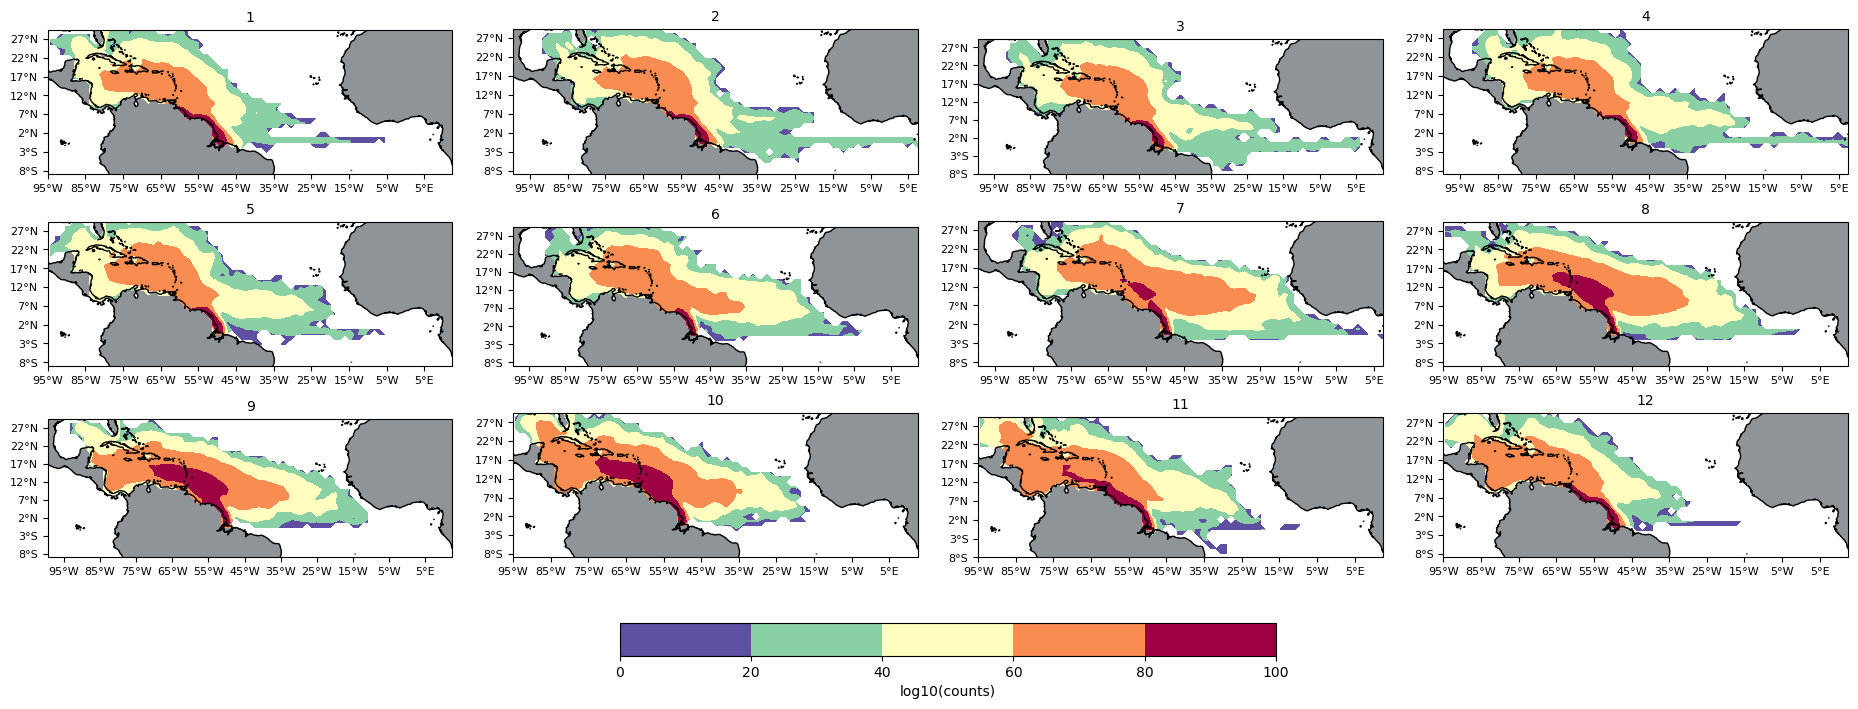

In [59]:
proj = ccrs.PlateCarree()

fig, ax = plt.subplots(
    3, 4,
    figsize=(20, 8),                      # a bit wider, not so tall
    subplot_kw=dict(projection=proj)
)
ax = ax.ravel()

for i in range(12):
    
    counts = hist_month.sel(start_month=i+1).sum("obs")
    dd = (np.log10(counts)/np.log10(counts.max()))*100
    # plot
    pcm = dd.plot.contourf(
        x='lon', y='lat', ax=ax[i], transform=proj,
        add_colorbar=False, cmap='Spectral_r'
    )

    ax[i].coastlines()
    ax[i].add_feature(cf.LAND, facecolor='#8e9497ff', zorder=0)
    ax[i].set_title(i+1, fontsize=10)

    # ticks & labels
    ax[i].set_xticks(
        np.arange(np.floor(dd.lon.min()), np.ceil(dd.lon.max()) + 1e-6, 10),
        crs=proj
    )
    ax[i].set_yticks(
        np.arange(np.floor(dd.lat.min()), np.ceil(dd.lat.max()) + 1e-6, 5),
        crs=proj
    )
    ax[i].xaxis.set_major_formatter(
        LongitudeFormatter(number_format='.0f', degree_symbol='°')
    )
    ax[i].yaxis.set_major_formatter(
        LatitudeFormatter(number_format='.0f', degree_symbol='°')
    )
    ax[i].tick_params(labelsize=8)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')

# Tighter spacing: reduce both wspace and hspace
fig.subplots_adjust(
    left=0.05, right=0.95,
    bottom=0.08, top=0.90,
    wspace=0.15, hspace=0.10
)

# Optional: one shared colorbar at bottom
cbar = fig.colorbar(
    pcm, ax=ax, orientation='horizontal',
    fraction=0.05, pad=0.10
)
cbar.ax.set_xlabel('log10(counts)', fontsize=10)

plt.show()

In [76]:
# counts = hist_month.isel(start_month=0).sum('obs')
## April to January
counts = (hist_month.isel(start_month=slice(3,12)).sum(dim='start_month') 
          + hist_month.isel(start_month=0)).sum(dim='obs')
counts.sum()

<xarray.DataArray 'histogram_lon_lat' ()> Size: 8B
array(9839138733)
Coordinates:
    start_month  int64 8B 1

Text(0.5, 1.0, 'April to January')

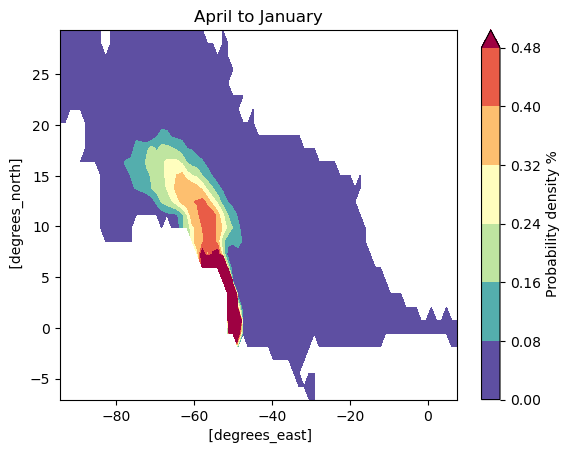

In [78]:
pp = (counts/counts.sum())
pp = pp.where(pp!=0, np.nan)
(pp*100).rename('Probability density %').plot.contourf(x='lon',y='lat',robust=True,cmap='Spectral_r')
plt.title('April to January')

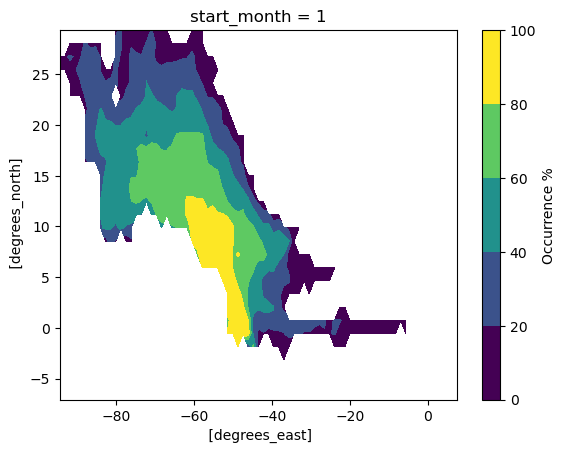

In [68]:
visited = (hist_month.isel(start_month=0) > 0).sum('obs')   # number of particles that ever visited
N = hist_month.sizes['obs']                                 # total particles
p_occ = (100 * visited / N).rename('Occurrence %')
p_occ = p_occ.where(p_occ!=0,np.nan)
p_occ.plot.contourf(x='lon', y='lat')

In [86]:
from scipy.ndimage import label, gaussian_filter
# 1) Extract blobs from PDF for each month
blobs_by_month = {}
for i in range(1):
    counts = hist_month.sel(start_month=i+1).sum("obs").fillna(0)
    pdf = counts / counts.sum()
    pdf_smooth = gaussian_filter(pdf.values, sigma=1.0)
    
    thresh = np.percentile(pdf_smooth[pdf_smooth > 0], 80)
    mask = pdf_smooth >= thresh
    
    blobs_by_month[i+1] = {
        'mask': mask,
        'pdf': pdf,
        'lon': pdf.lon.values,
        'lat': pdf.lat.values
    }

In [99]:
blobs_by_month

{1: {'mask': array([[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]], shape=(79, 29)),
  'pdf': <xarray.DataArray 'histogram_lon_lat' (lon: 79, lat: 29)> Size: 18kB
  array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          5.88803429e-08, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          1.58047236e-07, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          2.66511026e-07, 3.09896542e-09, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.0

In [41]:
(hist_month.isel(start_month=slice(4,12)).sum(dim='start_month') + hist_month.isel(start_month=1)).sum(dim='obs')

<xarray.DataArray 'histogram_lon_lat' (lon: 79, lat: 29)> Size: 18kB
array([[    0,     0,     0, ...,  1106,    94,  1388],
       [    0,     0,     0, ...,  7376,  2955,  3120],
       [    0,     0,     0, ..., 52285, 33384,  4046],
       ...,
       [    0,     0,     0, ...,     0,     0,     0],
       [    0,     0,     0, ...,     0,     0,     0],
       [    0,     0,     0, ...,     0,     0,     0]], shape=(79, 29))
Coordinates:
  * lon          (lon) float64 632B -94.31 -93.0 -91.7 ... 4.776 6.08 7.384
  * lat          (lat) float64 232B -7.067 -5.765 -4.464 ... 26.77 28.07 29.37
    start_month  int64 8B 2

## Others

In [6]:
ssh = xr.open_dataset('/work/bk1450/b383184/Amazon/Mercator/data/variables_c/tracers/SSH_1993-01c.nc')
ssh = ssh.compute()

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'sossheig' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [7]:
!ls -1 /work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U_* | wc -l

262


In [8]:
U = xr.open_mfdataset(
    '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/U*.nc',
    chunks={'time_counter':-1, 'deptht': 7, 'y': 250, 'x': 600},
).isel(deptht=slice(0, 7))
U = U.rename({"vozocrtx": "U"})
U

/tmp/ipykernel_1099873/3532554383.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 250. This could degrade performance. Instead, consider rechunking after loading.
  U = xr.open_mfdataset(
/tmp/ipykernel_1099873/3532554383.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 600. This could degrade performance. Instead, consider rechunking after loading.
  U = xr.open_mfdataset(
/tmp/ipykernel_1099873/3532554383.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 250. This could degrade performance. Instead, consider rechunking after loading.
  U = xr.open_mfdataset(
/tmp/ipykernel_1099873/3532554383.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 600. This could degrade performance. Instead, consider rechunking after loading.
  U = xr.open_mfdataset(
/tmp/ipykernel_10998

<xarray.Dataset> Size: 140GB
Dimensions:       (time_counter: 7973, deptht: 7, y: 499, x: 1260)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64kB 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB dask.array<chunksize=(250, 600), meta=np.ndarray>
    nav_lat       (y, x) float32 3MB dask.array<chunksize=(250, 600), meta=np.ndarray>
  * x             (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y             (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
  * deptht        (deptht) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93
Data variables:
    U             (time_counter, deptht, y, x) float32 140GB dask.array<chunksize=(31, 7, 250, 600), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Thu Nov 06 16:54:50 2025: cdo setmissval,nan U_1993-01.nc /...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [11]:
V = xr.open_mfdataset(
    '/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW/V*.nc',
    chunks={'time_counter':-1, 'deptht': 7, 'y': 250, 'x': 600},
).isel(deptht=slice(0, 7))
V = V.rename({"vomecrty": "V"})
V

<xarray.Dataset> Size: 140GB
Dimensions:       (time_counter: 7973, deptht: 7, y: 499, x: 1260)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64kB 1993-01-01T12:00:00 ... ...
    nav_lon       (y, x) float32 3MB dask.array<chunksize=(250, 600), meta=np.ndarray>
    nav_lat       (y, x) float32 3MB dask.array<chunksize=(250, 600), meta=np.ndarray>
  * x             (x) float64 10kB 2.306e+03 2.307e+03 ... 3.564e+03 3.565e+03
  * y             (y) float64 4kB 1.375e+03 1.376e+03 ... 1.872e+03 1.873e+03
  * deptht        (deptht) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93
Data variables:
    V             (time_counter, deptht, y, x) float32 140GB dask.array<chunksize=(31, 7, 250, 600), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Nov 07 00:01:55 2025: cdo setmissval,nan V_1993-01.nc /...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

In [12]:
U_T = (U.U.shift(x=1) + U.U)*0.5

V_T = (V.V.shift(y=1) + V.V)*0.5

In [ ]:
# U_T.mean("time_counter").compute()

2026-02-09 15:32:57,247 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:46873 -> tcp://127.0.0.1:34311
Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/tornado/iostream.py", line 1113, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^
ConnectionResetError: [Errno 104] Connection reset by peer

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/worker.py", line 1795, in get_data
    response = await comm.read(deserializers=serializers)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/work/bk1450/b

In [ ]:
# V_T.mean("time_counter").compute()

In [13]:
UV = xr.Dataset(
    data_vars={
        'U': (('time','depth','lat','lon'), U_T.data),
        'V': (('time','depth','lat', 'lon'), V_T.data),
    },
    coords={
        'time':U_T.time_counter.data,
        'depth':U_T.deptht.data,
        'lat':ssh.nav_lat.isel(x=0).data,
        'lon':ssh.nav_lon.isel(y=0).data,
    }
)
UV['UV'] = (UV.U**2+UV.V**2)**0.5
# UV = UV.persist()
UV

<xarray.Dataset> Size: 421GB
Dimensions:  (time: 7973, depth: 7, lat: 499, lon: 1260)
Coordinates:
  * time     (time) datetime64[ns] 64kB 1993-01-01T12:00:00 ... 2014-12-31T12...
  * depth    (depth) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917
Data variables:
    U        (time, depth, lat, lon) float32 140GB dask.array<chunksize=(5, 7, 250, 600), meta=np.ndarray>
    V        (time, depth, lat, lon) float32 140GB dask.array<chunksize=(5, 7, 250, 600), meta=np.ndarray>
    UV       (time, depth, lat, lon) float32 140GB dask.array<chunksize=(5, 7, 250, 600), meta=np.ndarray>

In [14]:
rms_speed = (((UV.U**2 + UV.V**2).mean(dim="time")))**0.5   # or dim="time"
# rms_speed = rms_speed.persist()
rms_speed

<xarray.DataArray (depth: 7, lat: 499, lon: 1260)> Size: 18MB
dask.array<pow, shape=(7, 499, 1260), dtype=float32, chunksize=(7, 250, 600), chunktype=numpy.ndarray>
Coordinates:
  * depth    (depth) float32 28B 0.494 1.541 2.646 3.819 5.078 6.441 7.93
  * lat      (lat) float32 2kB -9.95 -9.868 -9.785 -9.703 ... 29.77 29.84 29.91
  * lon      (lon) float32 5kB -95.0 -94.92 -94.83 -94.75 ... 9.75 9.833 9.917

In [ ]:
rms_speed.compute()

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 129.80 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:
rms_speed.drop_encoding().to_netcdf('UV_RMS.nc')

2026-02-09 14:26:09,228 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:33549 -> tcp://127.0.0.1:40291
Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/tornado/iostream.py", line 1113, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^
ConnectionResetError: [Errno 104] Connection reset by peer

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/worker.py", line 1795, in get_data
    response = await comm.read(deserializers=serializers)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/work/bk1450/b

In [ ]:
uv = UV.UV.mean(dim='depth')
uv = uv.chunk({'time': 20, 'lat': -1, 'lon':-1})
uv=uv.persist()
uv
# uv.isel(time=0).load().plot()
# uv.drop_encoding().to_netcdf('UV_all_time.nc')
# uv.to_netcdf('UV_all_time.nc')

In [ ]:
UV_mean = xr.open_dataset('UV_0_7m.nc')
UV_mean = UV_mean.compute()
UV_mean

In [ ]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

In [ ]:
seasonality(UV_mean).UV.plot.contourf(x="lon", y="lat", col="month", col_wrap=4,robust=True)